# Club & League Insights

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# import data
df = pd.read_csv("players_data-2024_2025.csv")
Comp = df['Comp'].value_counts().head(5).index
df_top5_comp = df[df['Comp'].isin(Comp)]

## the top 5 clubs that scored the most goals.

Text(0, 0.5, 'Goals')

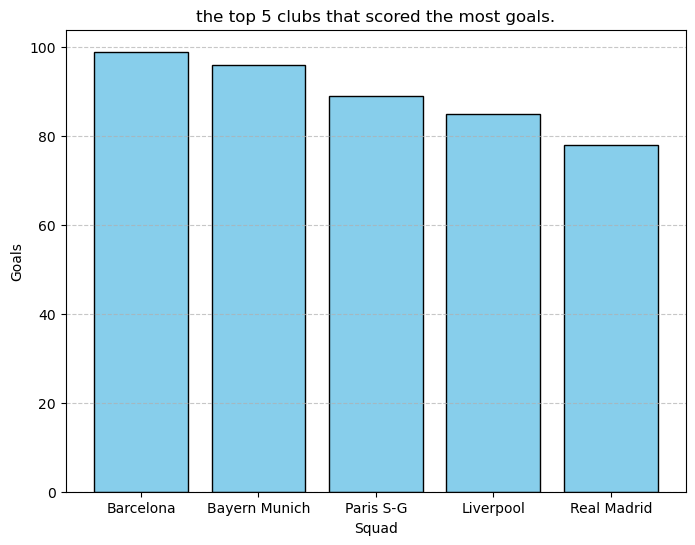

In [3]:
most_club = df_top5_comp.groupby('Squad')['Gls'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,6))

plt.bar(most_club.index, most_club.values, edgecolor='black', color='skyblue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("the top 5 clubs that scored the most goals.")
plt.xlabel('Squad')
plt.ylabel('Goals')

## the top 5 clubs that scored the most goals.

Comp
eng Premier League    1082
es La Liga             969
de Bundesliga          934
it Serie A             933
fr Ligue 1             885
Name: Gls, dtype: int64


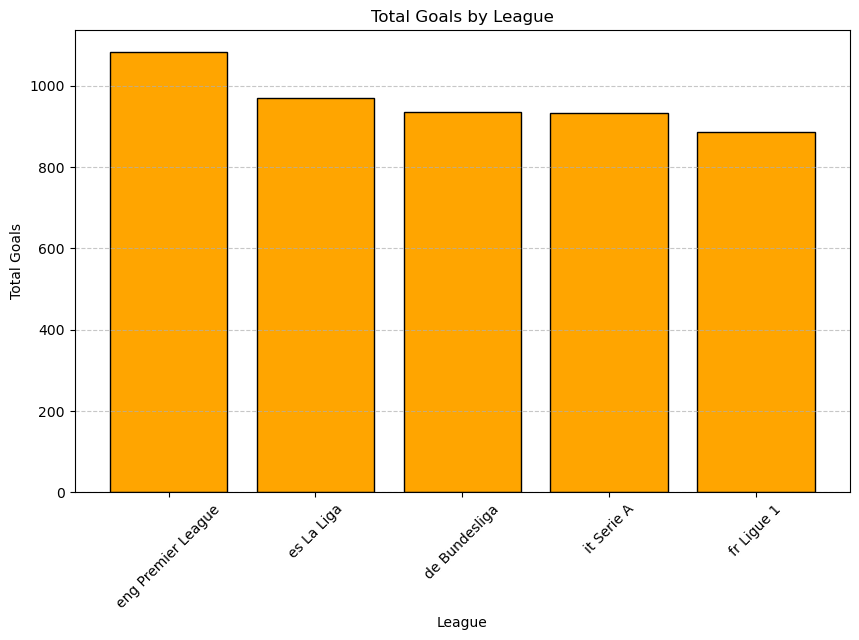

In [4]:

goals_by_league = df_top5_comp.groupby('Comp')['Gls'].sum().sort_values(ascending=False)
print(goals_by_league)
plt.figure(figsize=(10,6))
plt.bar(goals_by_league.index, goals_by_league.values, color='orange', edgecolor='black')
plt.title("Total Goals by League")
plt.xlabel("League")
plt.ylabel("Total Goals")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


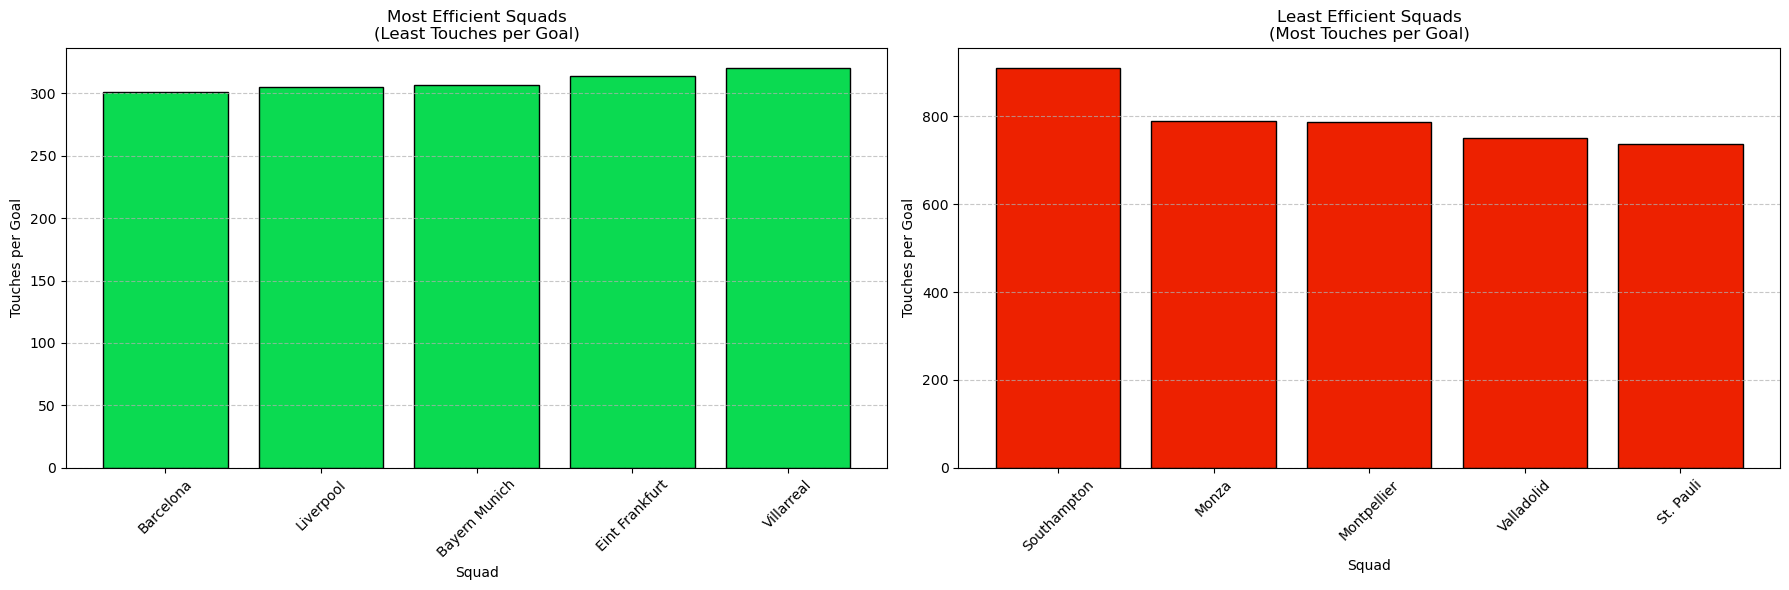

In [33]:
squad_efficiency = df_top5_comp.groupby('Squad')[['Gls', 'Touches']].sum()
squad_efficiency['Touch_per_Goals'] = squad_efficiency['Touches'] / squad_efficiency['Gls']

squad_efficiency_less = squad_efficiency.sort_values('Touch_per_Goals', ascending=True).head()
squad_efficiency_more = squad_efficiency.sort_values('Touch_per_Goals', ascending=False).head()
fig, ax = plt.subplots(1, 2, figsize=(18,6))

ax[0].bar(squad_efficiency_less.index, squad_efficiency_less['Touch_per_Goals'], edgecolor='black', color='#0BDA51')

ax[0].set_title('Most Efficient Squads\n(Least Touches per Goal)')
ax[0].set_xlabel('Squad')
ax[0].set_ylabel('Touches per Goal')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)


ax[1].bar(squad_efficiency_more.index, squad_efficiency_more['Touch_per_Goals'], edgecolor='black', color='#ED2100')

ax[1].set_title('Least Efficient Squads\n(Most Touches per Goal)')
ax[1].set_xlabel('Squad')
ax[1].set_ylabel('Touches per Goal')
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
total_goals = df_top5_comp.groupby('Squad')['Gls'].sum().sort_values(ascending=False).head(5)
top_scorer = df_top5_comp.groupby('Squad')['Gls'].max()
dependency = pd.DataFrame({
    'Total_Goals': total_goals,
    'Top_Scorer_Goals': top_scorer
})
dependency['Star_Dependency_%'] = (dependency['Top_Scorer_Goals'] / dependency['Total_Goals']) * 100

dependency.sort_values('Star_Dependency_%', ascending=False).head()

plt1

,Total_Goals,Top_Scorer_Goals,Star_Dependency_%
Squad,,,
Real Madrid,78.0,31,39.743590
Liverpool,85.0,29,34.117647
Barcelona,99.0,27,27.272727
Bayern Munich,96.0,26,27.083333
Paris S-G,89.0,21,23.595506
